# Modelos de Classificação

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import linear_model, tree, naive_bayes
from pathlib import Path


data = Path('../data')
df = pd.read_excel(data/'dados_cerveja_nota.xlsx')
df

,id,cerveja,nota
0,1,1,0.75
1,2,1,3.00
2,3,2,1.75
3,4,3,1.75
4,5,4,4.20
5,6,4,6.50
6,7,5,2.90
7,8,6,6.20
8,9,6,7.00
9,10,7,6.20


In [19]:
df['aprovado'] = (df['nota'] > 5).astype(int)
df

,id,cerveja,nota,aprovado
0,1,1,0.75,0
1,2,1,3.00,0
2,3,2,1.75,0
3,4,3,1.75,0
4,5,4,4.20,0
5,6,4,6.50,1
6,7,5,2.90,0
7,8,6,6.20,1
8,9,6,7.00,1
9,10,7,6.20,1


> Plot de Aprovados e Não aprovados em função da quantidade de cervejas ingeridas

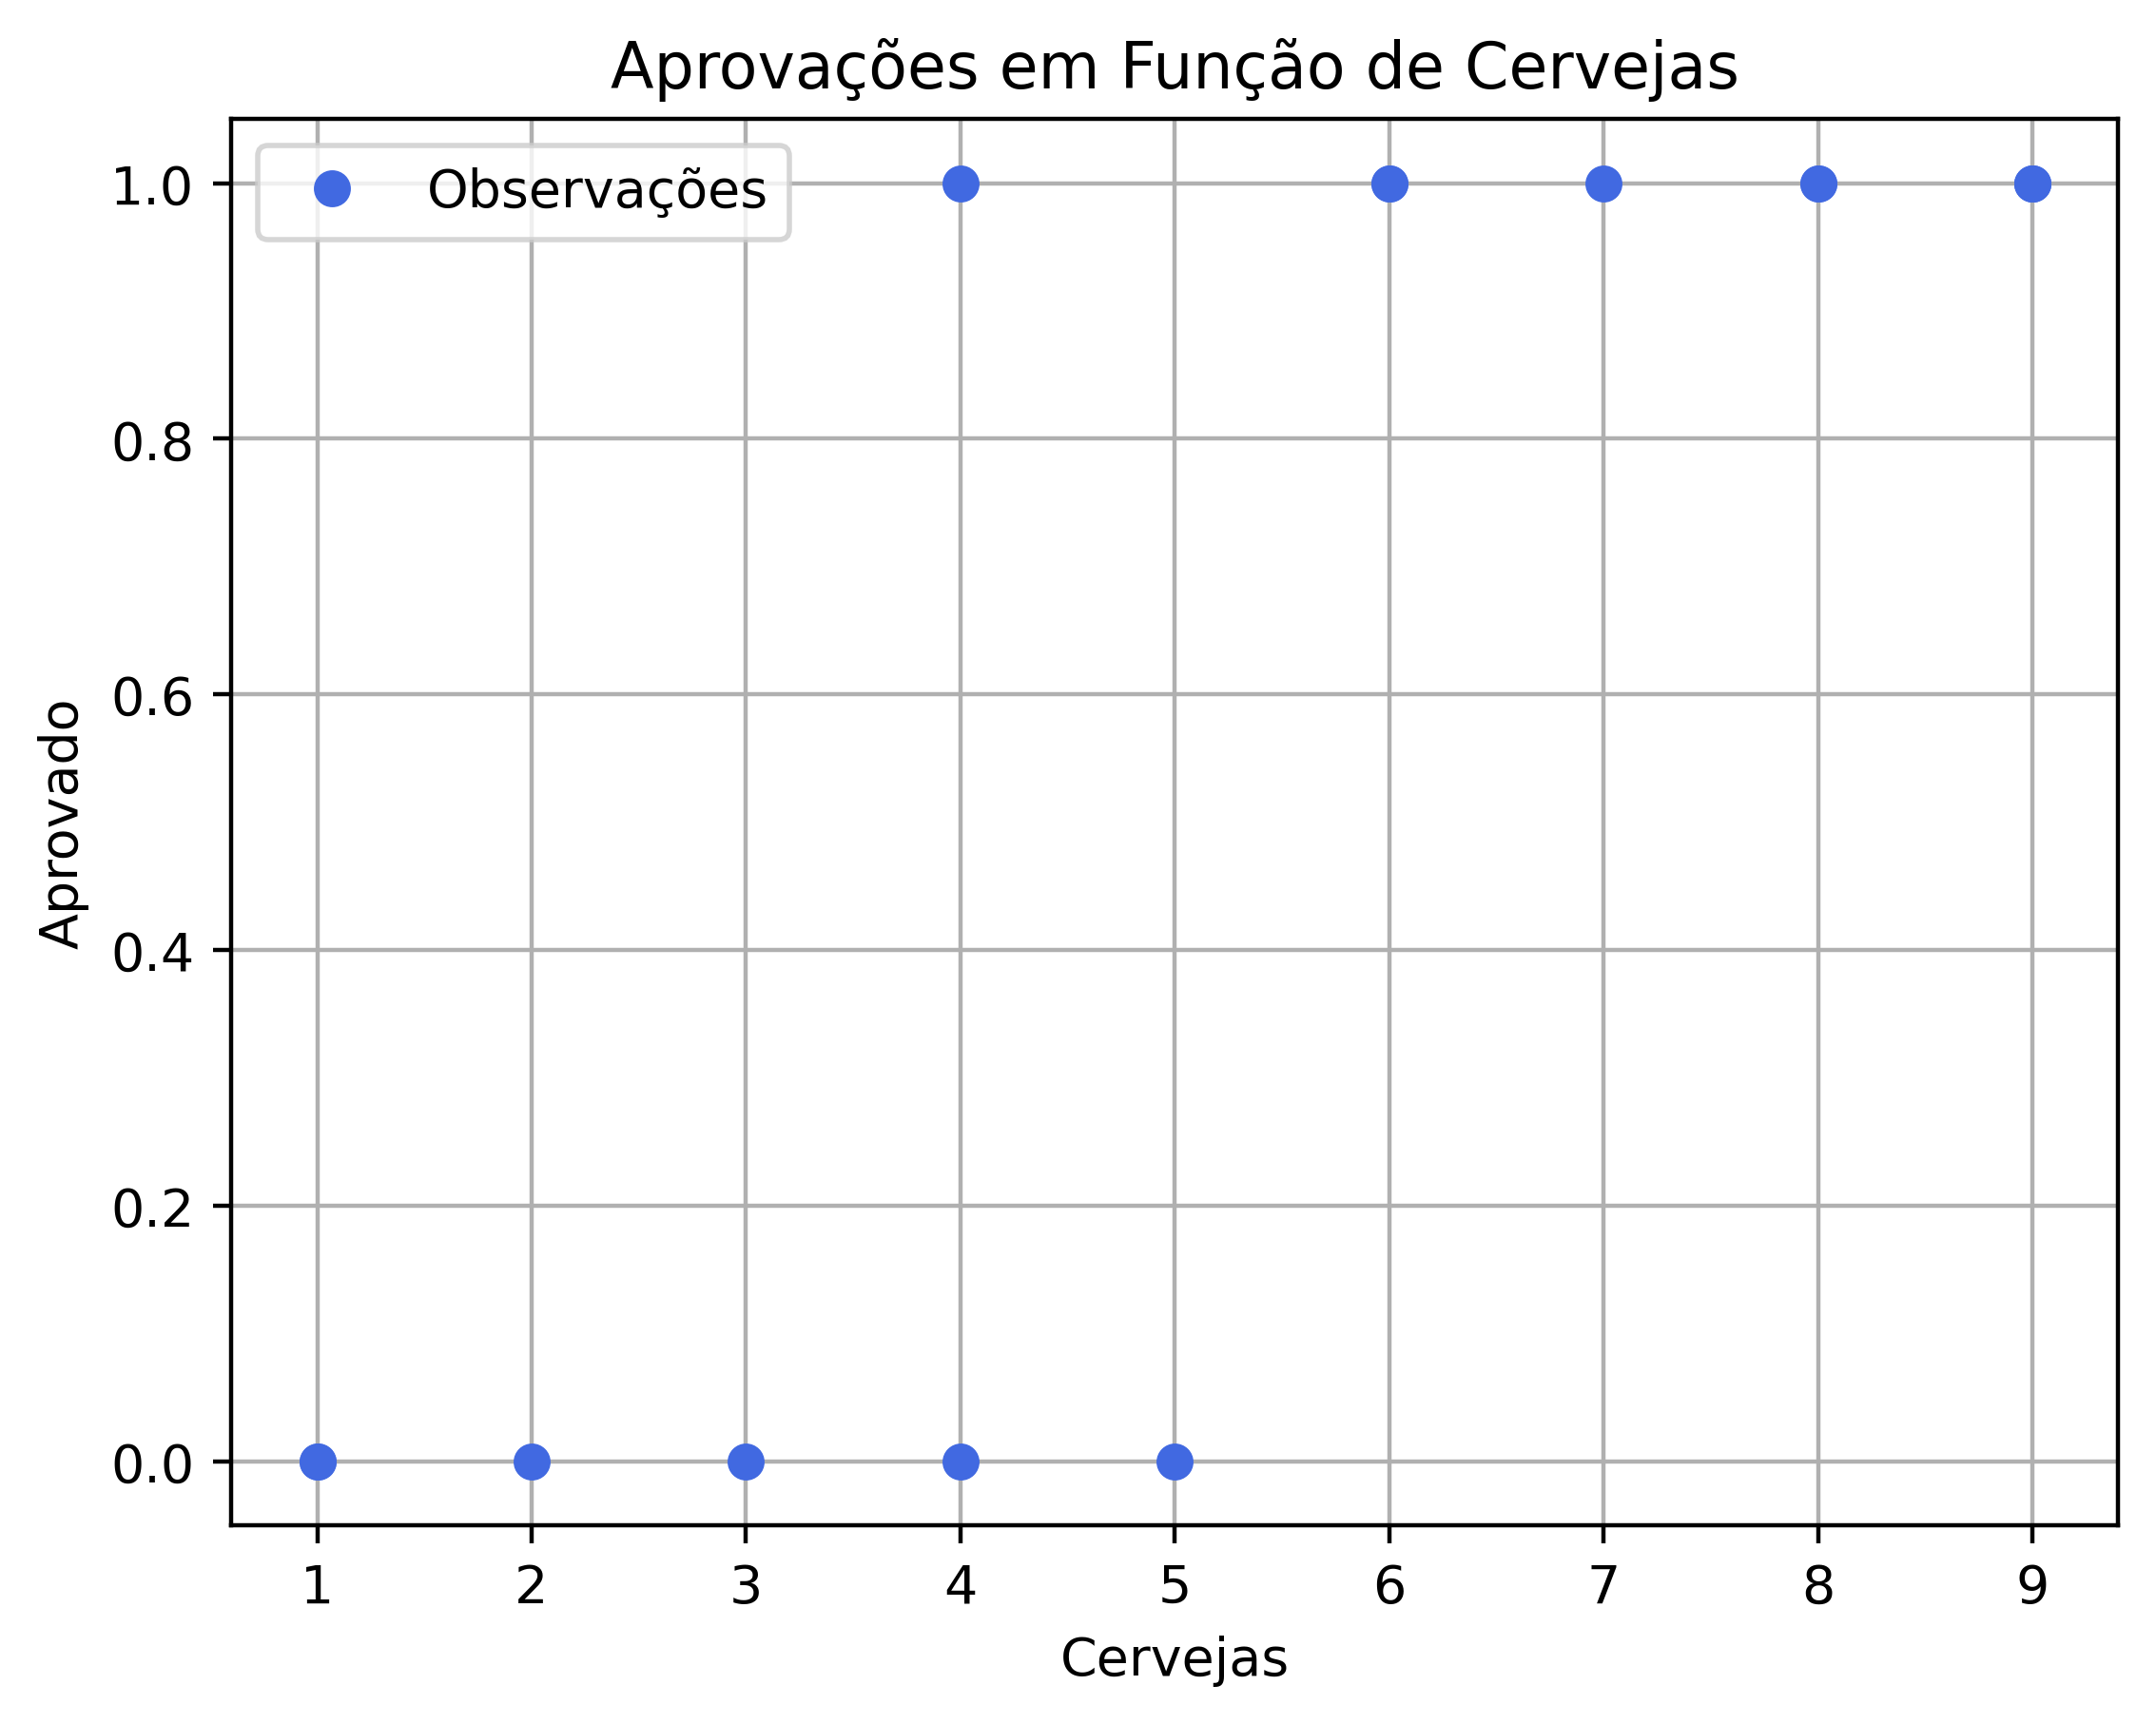

In [20]:
plt.figure(dpi=400)
plt.plot(df[['cerveja']], df['aprovado'], 'o', color="royalblue")

plt.title('Aprovações em Função de Cervejas')
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")

plt.legend(["Observações"])
plt.grid(True)
plt.show()

> Regressão Logística e Árvore de Decisão sem parâmetro de parada

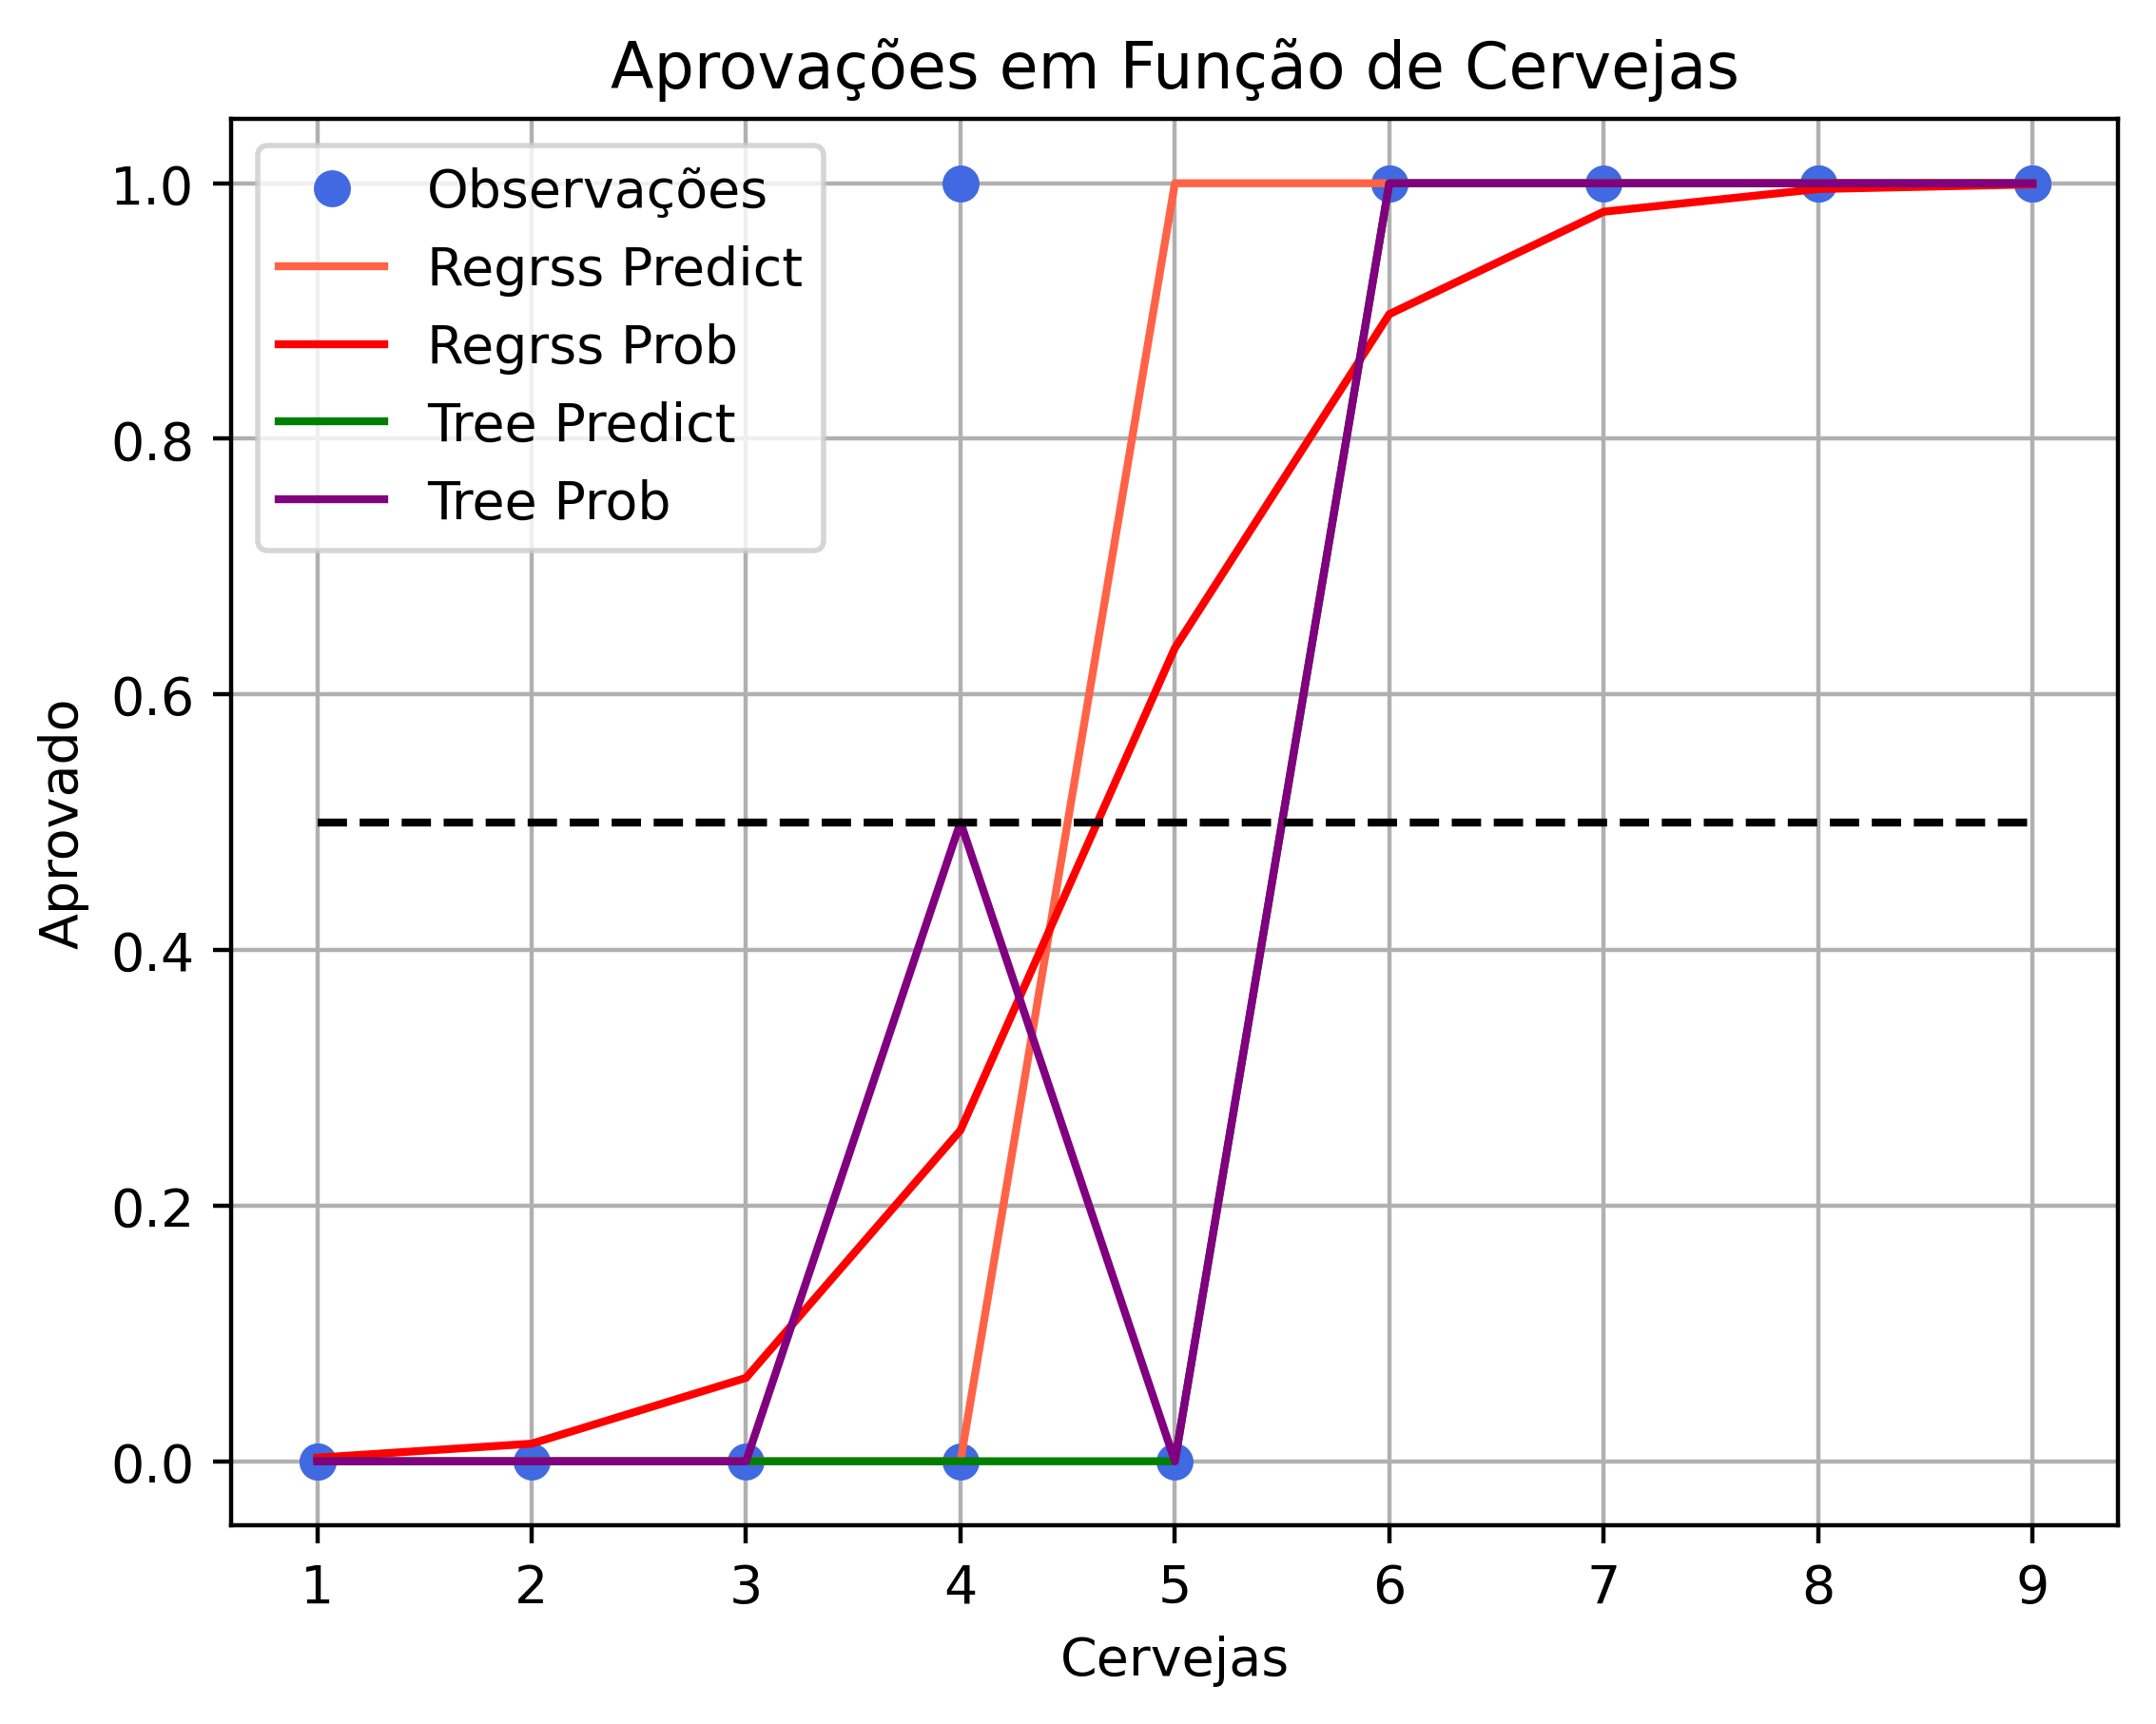

In [21]:
reg_model = linear_model.LogisticRegression(
    penalty=None,
    fit_intercept=True,
)

features = ['cerveja']
target = 'aprovado'

X = df[features]
y = df[target]

reg_model.fit(X, y)

predict = reg_model.predict(df[['cerveja']].drop_duplicates())
proba = reg_model.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

arvore_full = tree.DecisionTreeClassifier(random_state=42)

arvore_full.fit(X, y)

arvore_full_predict = arvore_full.predict(df[['cerveja']].drop_duplicates())
arvore_full_proba = arvore_full.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

plt.figure(dpi=400)
plt.plot(df[['cerveja']], df['aprovado'], 'o', color="royalblue")

plt.plot(df['cerveja'].drop_duplicates(), predict, color='tomato')
plt.plot(df['cerveja'].drop_duplicates(), proba, color='red')

plt.plot(df['cerveja'].drop_duplicates(), arvore_full_predict, color='green')
plt.plot(df['cerveja'].drop_duplicates(), arvore_full_proba, color='purple')

plt.title('Aprovações em Função de Cervejas')
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")
plt.hlines(.5, xmin=1, xmax=9, linestyles='--', colors='black')

plt.legend(['Observações', 'Regrss Predict', 'Regrss Prob', 'Tree Predict', 'Tree Prob'])
plt.grid(True)
plt.show()

> Adicionada Árvoce de Decisão com no Máximo 2 nós de profundidade

- Podemos ver que Árvore com max 2 de profundidade pereforma melhor na probabilidade e predição

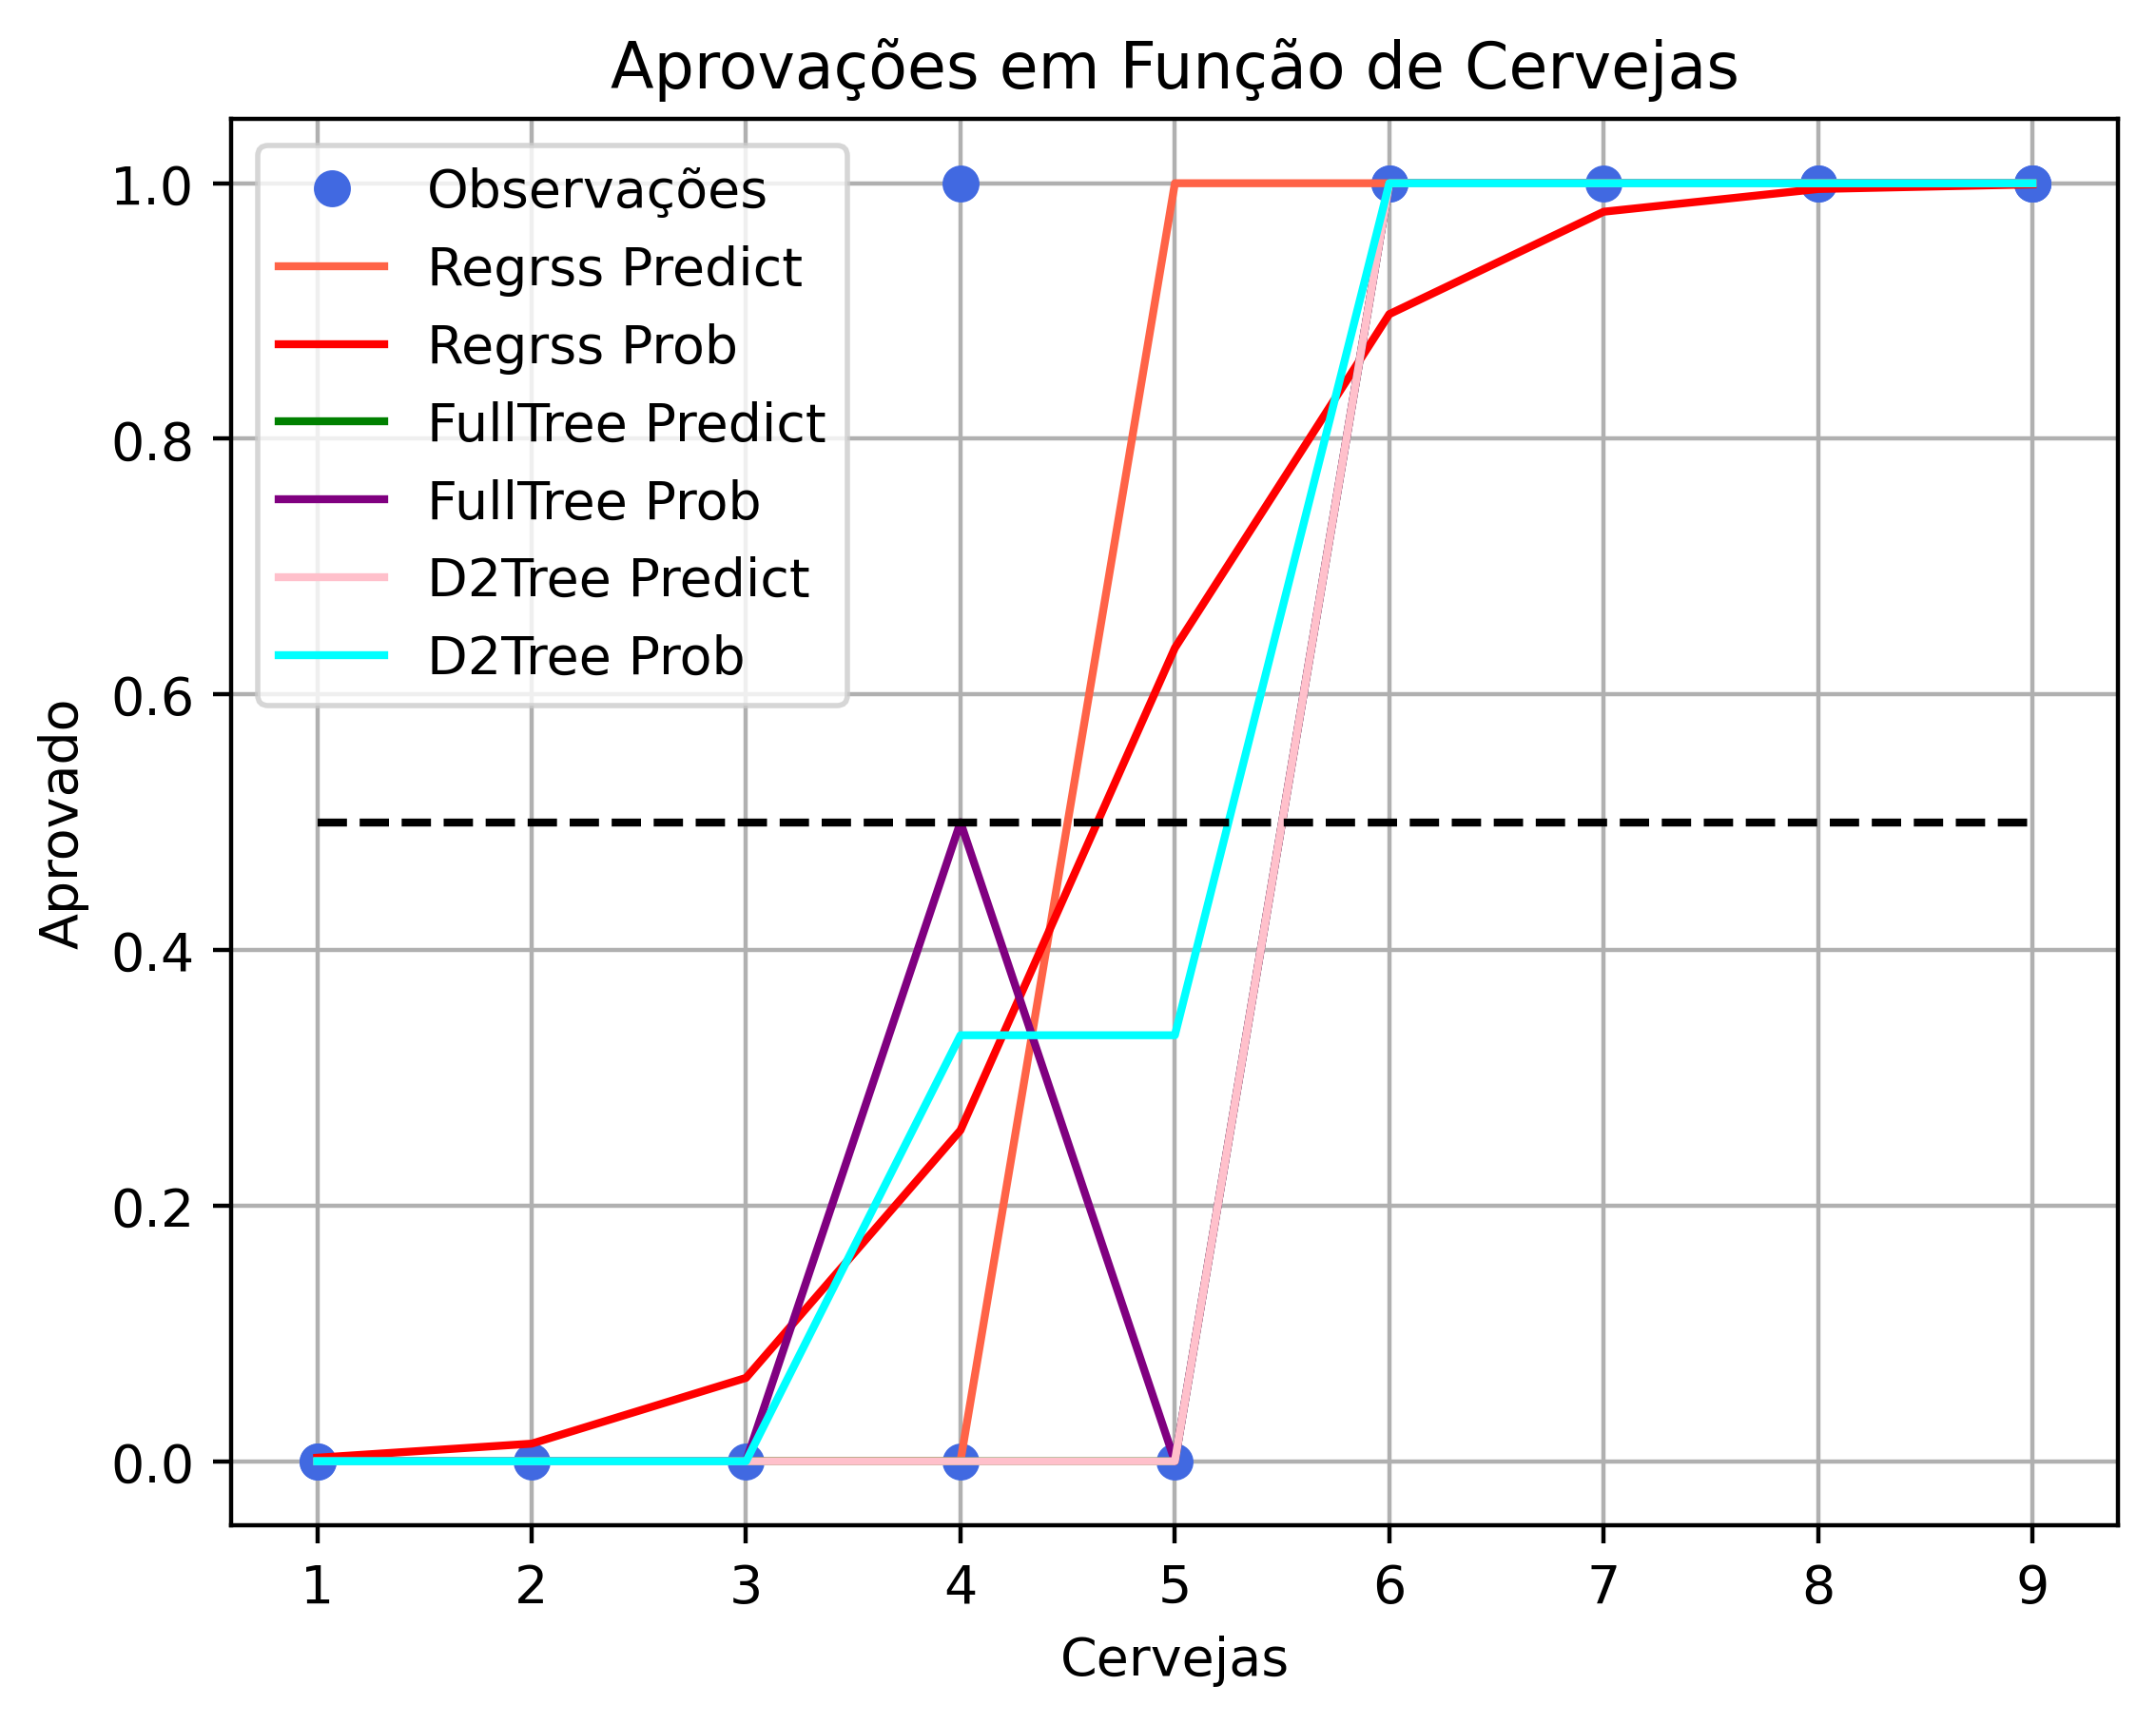

In [22]:
reg_model = linear_model.LogisticRegression(
    penalty=None,
    fit_intercept=True,
)

features = ['cerveja']
target = 'aprovado'

X = df[features]
y = df[target]

reg_model.fit(X, y)

predict = reg_model.predict(df[['cerveja']].drop_duplicates())
proba = reg_model.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

arvore_full = tree.DecisionTreeClassifier(random_state=42)
arvore_full.fit(X, y)
arvore_full_predict = arvore_full.predict(df[['cerveja']].drop_duplicates())
arvore_full_proba = arvore_full.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

arvore_d2 = tree.DecisionTreeClassifier(max_depth=2, random_state=42)
arvore_d2.fit(X, y)
arvore_d2_predict = arvore_d2.predict(df[['cerveja']].drop_duplicates())
arvore_d2_proba = arvore_d2.predict_proba(df[['cerveja']].drop_duplicates())[:, 1]

plt.figure(dpi=400)
plt.plot(df[['cerveja']], df['aprovado'], 'o', color="royalblue")

plt.plot(df['cerveja'].drop_duplicates(), predict, color='tomato')
plt.plot(df['cerveja'].drop_duplicates(), proba, color='red')

plt.plot(df['cerveja'].drop_duplicates(), arvore_full_predict, color='green')
plt.plot(df['cerveja'].drop_duplicates(), arvore_full_proba, color='purple')

plt.plot(df['cerveja'].drop_duplicates(), arvore_d2_predict, color='pink')
plt.plot(df['cerveja'].drop_duplicates(), arvore_d2_proba, color='Cyan')

plt.title('Aprovações em Função de Cervejas')
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")
plt.hlines(.5, xmin=1, xmax=9, linestyles='--', colors='black')

plt.legend(['Observações', 'Regrss Predict', 'Regrss Prob', 'FullTree Predict', 'FullTree Prob', 'D2Tree Predict', 'D2Tree Prob'])
plt.grid(True)
plt.show()

> Adicionado Modelo Naive Bayes

- O modelo performa ainda melhor em 

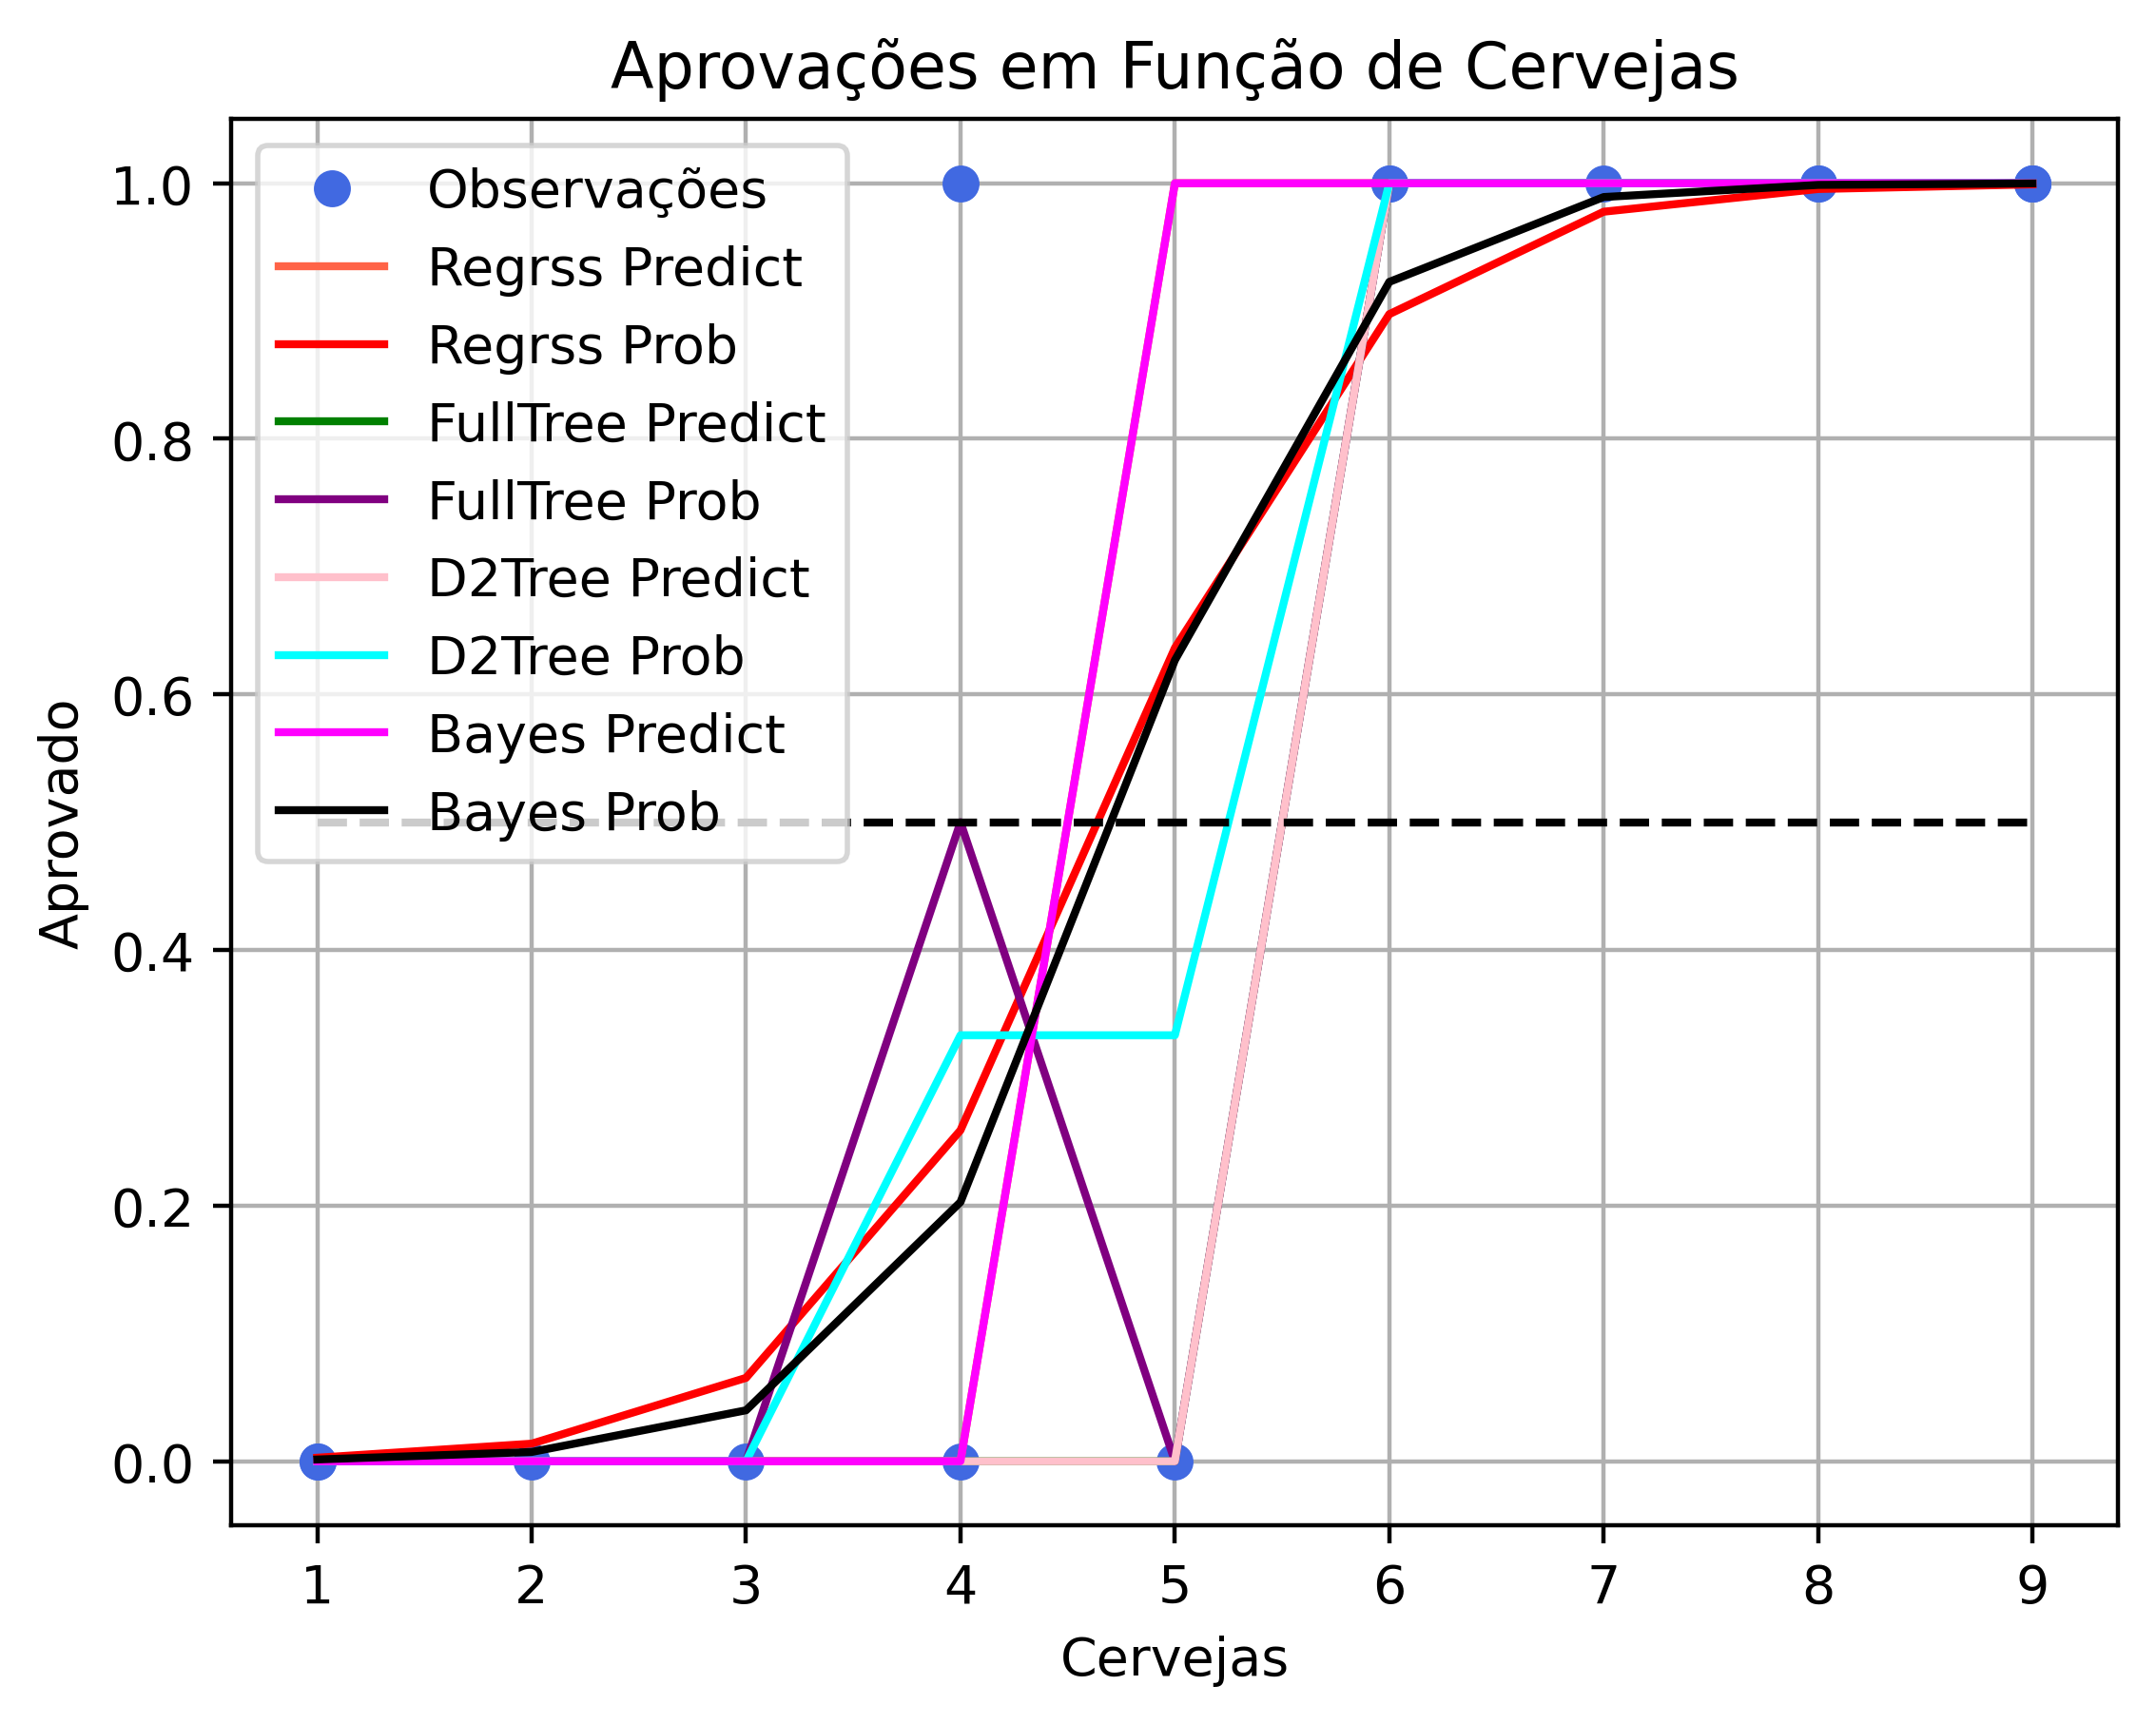

In [23]:
reg_model = linear_model.LogisticRegression(
    penalty=None,
    fit_intercept=True,
)

features = ['cerveja']
target = 'aprovado'

X = df[features]
y = df[target]

reg_model.fit(X, y)

predict = reg_model.predict(X.drop_duplicates())
proba = reg_model.predict_proba(X.drop_duplicates())[:, 1]

arvore_full = tree.DecisionTreeClassifier(random_state=42)
arvore_full.fit(X, y)
arvore_full_predict = arvore_full.predict(X.drop_duplicates())
arvore_full_proba = arvore_full.predict_proba(X.drop_duplicates())[:, 1]

arvore_d2 = tree.DecisionTreeClassifier(max_depth=2, random_state=42)
arvore_d2.fit(X, y)
arvore_d2_predict = arvore_d2.predict(X.drop_duplicates())
arvore_d2_proba = arvore_d2.predict_proba(X.drop_duplicates())[:, 1]

nb = naive_bayes.GaussianNB()
nb.fit(X, y)
bayes_predict = nb.predict(X.drop_duplicates())
bayes_proba = nb.predict_proba(X.drop_duplicates())[:, 1]

plt.figure(dpi=400)
plt.plot(X, y, 'o', color="royalblue")

plt.plot(X.drop_duplicates(), predict, color='tomato')
plt.plot(X.drop_duplicates(), proba, color='red')

plt.plot(X.drop_duplicates(), arvore_full_predict, color='green')
plt.plot(X.drop_duplicates(), arvore_full_proba, color='purple')

plt.plot(X.drop_duplicates(), arvore_d2_predict, color='pink')
plt.plot(X.drop_duplicates(), arvore_d2_proba, color='cyan')

plt.plot(X.drop_duplicates(), bayes_predict, color='magenta')
plt.plot(X.drop_duplicates(), bayes_proba, color='black')

plt.title('Aprovações em Função de Cervejas')
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")
plt.hlines(.5, xmin=1, xmax=9, linestyles='--', colors='black')

plt.legend(['Observações', 'Regrss Predict', 'Regrss Prob', 'FullTree Predict', 'FullTree Prob', 'D2Tree Predict', 'D2Tree Prob', 'Bayes Predict', 'Bayes Prob'])
plt.grid(True)
plt.show()

> Comparação somente entre Bayes e Regressão

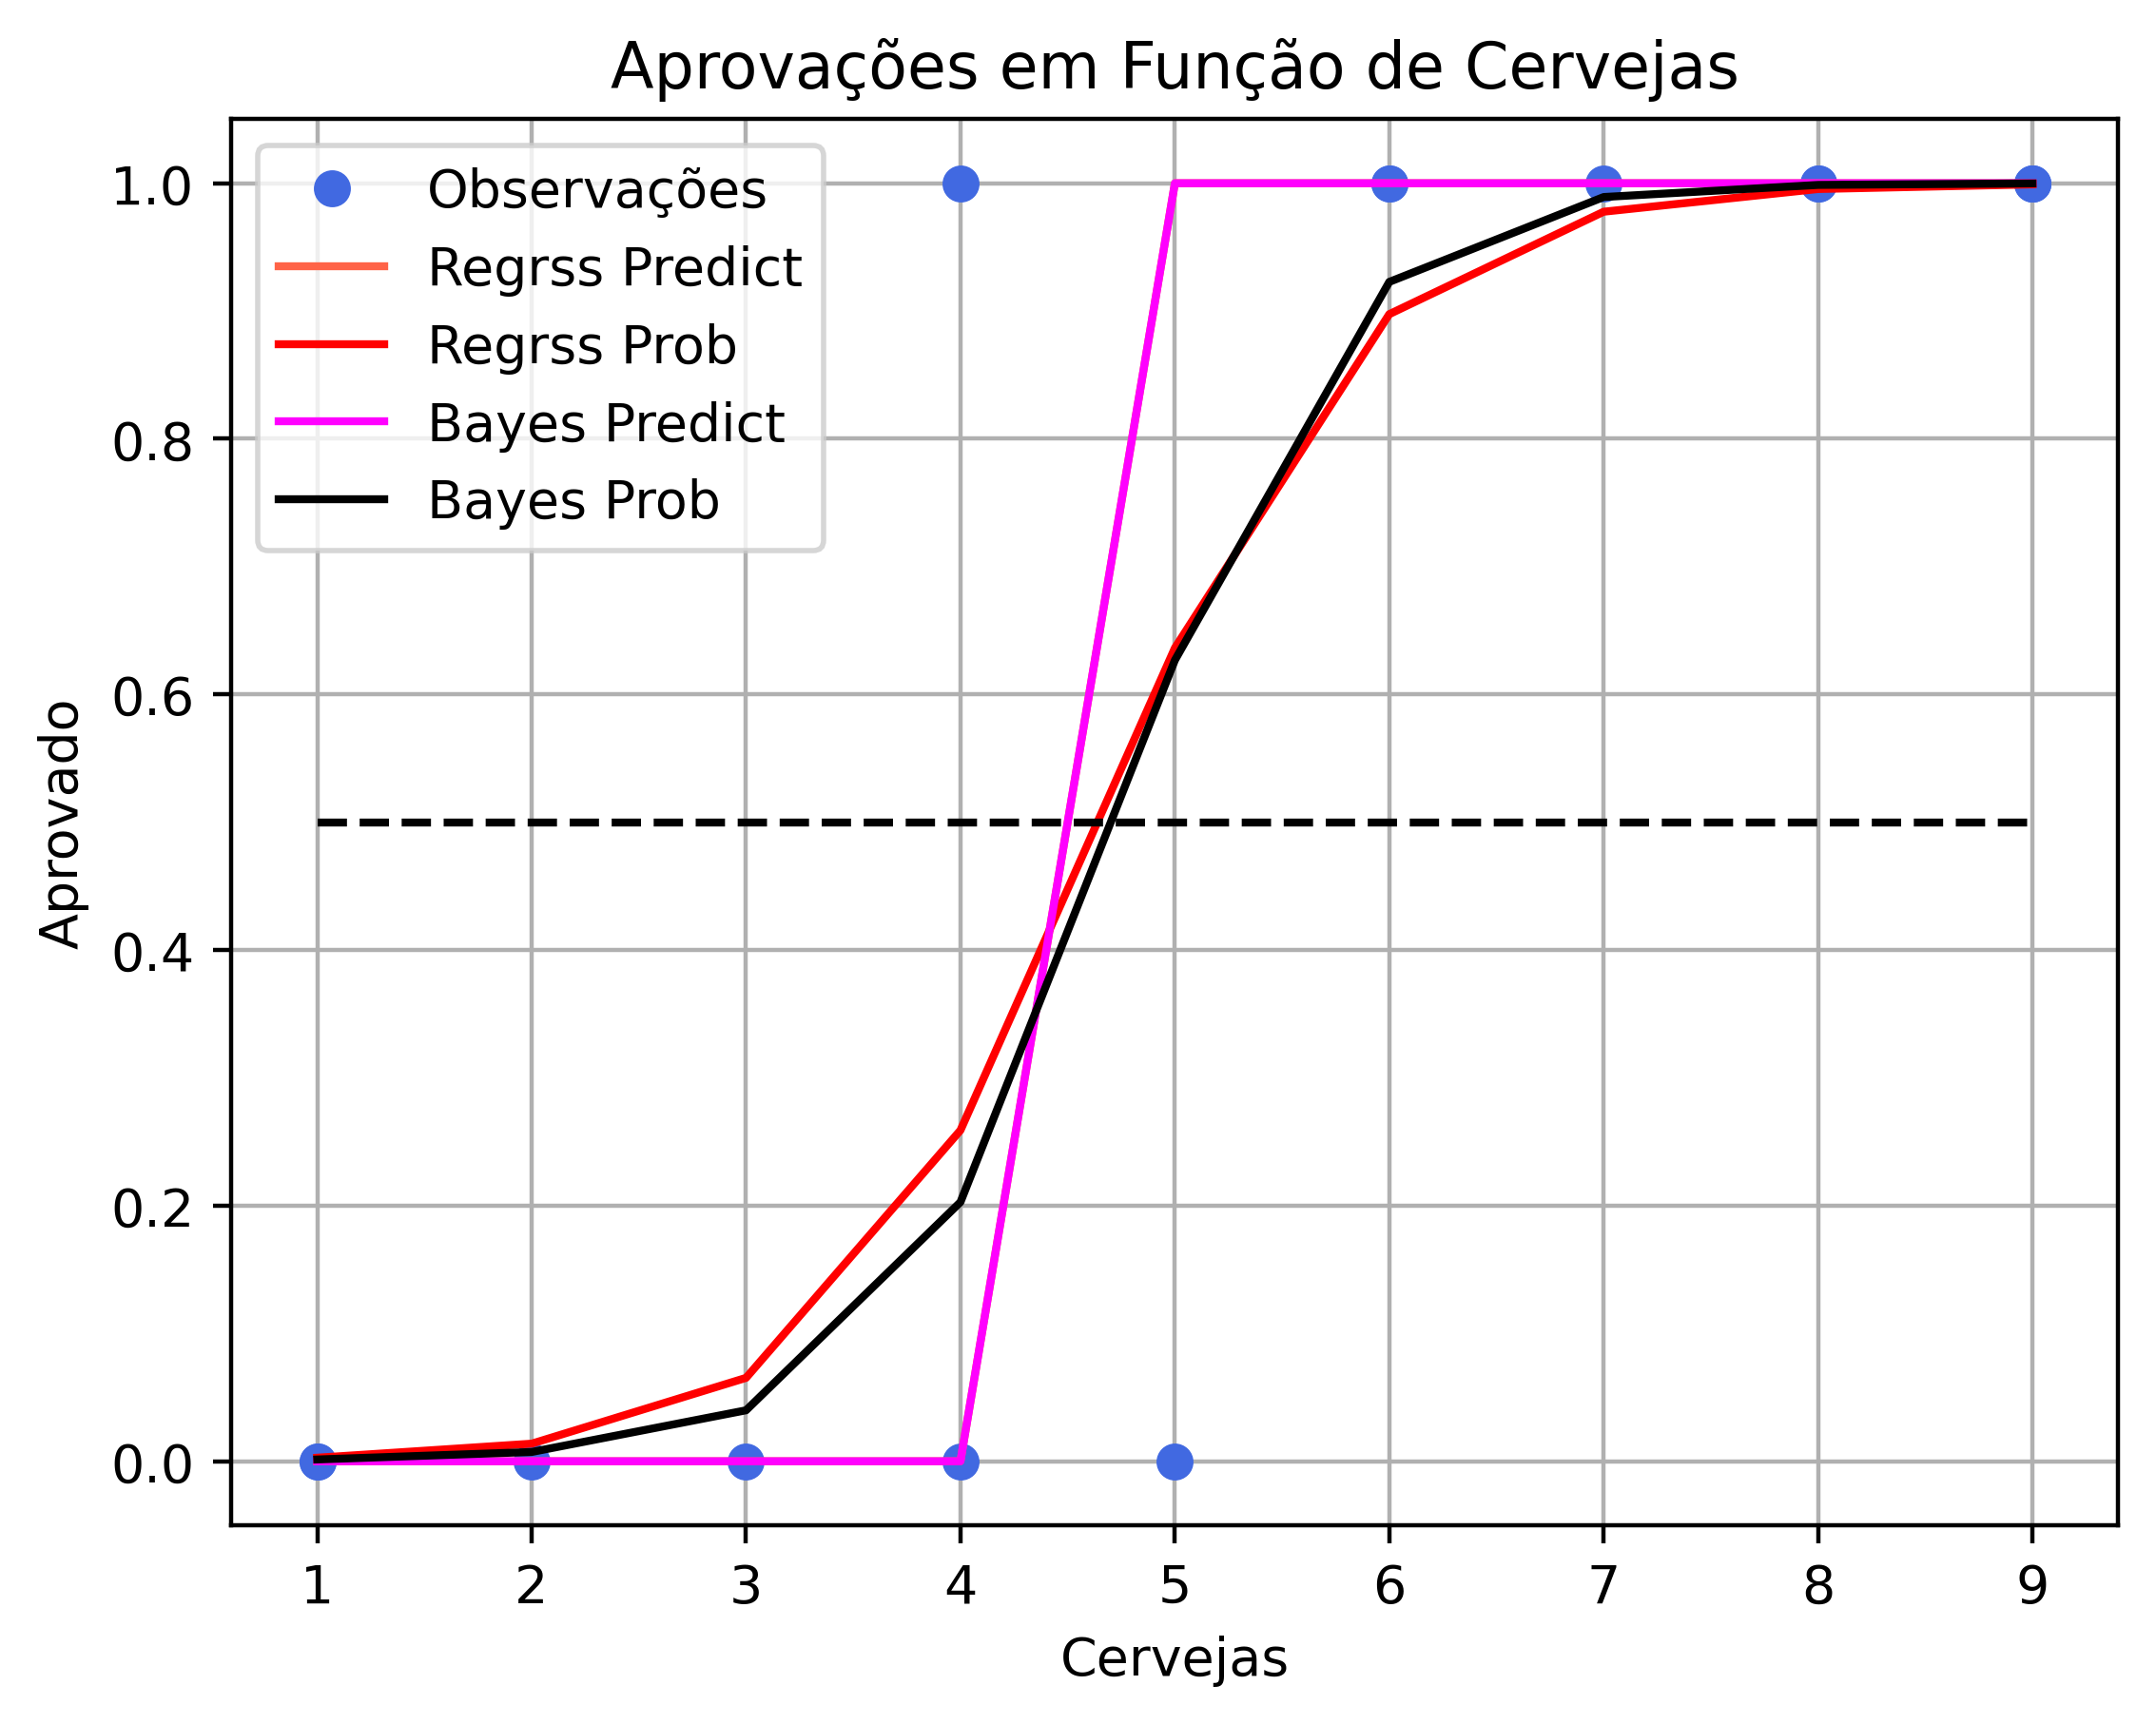

In [24]:
features = ['cerveja']
target = 'aprovado'

X = df[features]
y = df[target]

reg_model = linear_model.LogisticRegression(
    penalty=None,
    fit_intercept=True,
)
reg_model.fit(X, y)
predict = reg_model.predict(X.drop_duplicates())
proba = reg_model.predict_proba(X.drop_duplicates())[:, 1]

nb = naive_bayes.GaussianNB()
nb.fit(X, y)
bayes_predict = nb.predict(X.drop_duplicates())
bayes_proba = nb.predict_proba(X.drop_duplicates())[:, 1]

plt.figure(dpi=400)
plt.plot(X, y, 'o', color="royalblue")

plt.plot(X.drop_duplicates(), predict, color='tomato')
plt.plot(X.drop_duplicates(), proba, color='red')

plt.plot(X.drop_duplicates(), bayes_predict, color='magenta')
plt.plot(X.drop_duplicates(), bayes_proba, color='black')

plt.title('Aprovações em Função de Cervejas')
plt.xlabel("Cervejas")
plt.ylabel("Aprovado")
plt.hlines(.5, xmin=1, xmax=9, linestyles='--', colors='black')

plt.legend(['Observações', 'Regrss Predict', 'Regrss Prob', 'Bayes Predict', 'Bayes Prob'])
plt.grid(True)
plt.show()